# 06a — E3b Validation-Based Video Threshold Selection

This notebook selects a secondary operating threshold for the retained **E3b official-SBI EfficientNet-B0 checkpoint**. The threshold is selected **only** from genuine, dataset-provided FaceForensics++ validation videos. It is then frozen and applied unchanged to the held-out FaceForensics++ test set and the fixed Celeb-DF v2 pilot.

The original threshold of $0.5$ remains the canonical dissertation result. The selected threshold defines the application-oriented configuration **E3b-T**; it is not a newly trained model.

## 1. Run controls and selection rule

The primary selection criterion is video-level macro F1. Ties are resolved by higher fake recall and then by proximity to 0.5. Neither FaceForensics++ test labels nor Celeb-DF v2 labels participate in threshold selection.

In [1]:
INSTALL_DEPENDENCIES = False
RUN_VALIDATION_SELECTION = True
RUN_FFPP_TEST_COMPARISON = True
RUN_CELEBDF_COMPARISON = True

DEFAULT_THRESHOLD = 0.5
CANDIDATE_THRESHOLDS = [round(value, 2) for value in np.arange(0.01, 1.00, 0.01)] if "np" in globals() else None
BATCH_SIZE = 32
NUM_WORKERS = 2
SELECTION_METRIC = "video_macro_f1"
TIE_BREAK_RULE = "higher fake recall, then threshold closest to 0.5, then lower threshold"

## 2. Environment and canonical paths

In [3]:
if INSTALL_DEPENDENCIES:
    !pip -q install scikit-learn seaborn

from google.colab import drive
drive.mount("/content/drive")

import json
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision.models import efficientnet_b0

CANDIDATE_THRESHOLDS = [round(value, 2) for value in np.arange(0.01, 1.00, 0.01)]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_PATH = Path("/content/drive/MyDrive/deepfake_project")
FFPP_VAL_DIR = BASE_PATH / "face_dataset" / "val"
FFPP_TEST_DIR = BASE_PATH / "face_dataset" / "test"
FFPP_MANIFEST_PATH = BASE_PATH / "ffpp_video_split_manifest.json"

CELEB_FACES_DIR = BASE_PATH / "celebdf_v2" / "pilot_faces"
CELEB_MANIFEST_PATH = BASE_PATH / "celebdf_v2" / "celebdf_pilot_manifest.json"

CHECKPOINT_PATH = BASE_PATH / "saved_models" / "efficientnet_b0_official_sbi_best.pth"
RESULTS_DIR = BASE_PATH / "results" / "threshold_selection"
PLOTS_DIR = BASE_PATH / "plots" / "threshold_selection"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SELECTION_JSON = RESULTS_DIR / "e3b_validation_threshold_selection.json"
SEARCH_CSV = RESULTS_DIR / "e3b_validation_threshold_search.csv"
COMPARISON_CSV = RESULTS_DIR / "e3b_threshold_comparison.csv"
PREDICTIONS_CSV = RESULTS_DIR / "e3b_video_probabilities_all_domains.csv"

for required_path in (
    FFPP_VAL_DIR / "real", FFPP_VAL_DIR / "fake",
    FFPP_TEST_DIR / "real", FFPP_TEST_DIR / "fake",
    FFPP_MANIFEST_PATH, CHECKPOINT_PATH,
):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

print("Device:", DEVICE)
print("Checkpoint:", CHECKPOINT_PATH)
print("Selection data:", FFPP_VAL_DIR)

Mounted at /content/drive
Device: cuda
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b0_official_sbi_best.pth
Selection data: /content/drive/MyDrive/deepfake_project/face_dataset/val


## 3. E3b-compatible data loading and split audit

In [4]:
IMAGE_SIZE = 224
REAL_INDEX = 0
FAKE_INDEX = 1
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def image_to_tensor(image_rgb):
    image = cv2.resize(image_rgb, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)
    image = image.astype(np.float32) / 255.0
    image = image.transpose(2, 0, 1)
    return torch.tensor(image, dtype=torch.float32)

def ffpp_video_id(path):
    stem = Path(path).stem
    if "_frame_" not in stem:
        raise ValueError(f"Cannot recover FF++ source-video id from: {Path(path).name}")
    return stem.rsplit("_frame_", 1)[0]

def celeb_video_id(path):
    stem = Path(path).stem
    if "__frame_" not in stem:
        raise ValueError(f"Cannot recover Celeb-DF source-video id from: {Path(path).name}")
    return stem.split("__frame_", 1)[0]

class FaceCropDataset(Dataset):
    def __init__(self, root, parser):
        self.samples = []
        for class_name, label in (("real", REAL_INDEX), ("fake", FAKE_INDEX)):
            class_dir = Path(root) / class_name
            if not class_dir.is_dir():
                raise FileNotFoundError(class_dir)
            for path in sorted(class_dir.iterdir()):
                if path.suffix.lower() in VALID_EXTENSIONS:
                    self.samples.append({
                        "path": path,
                        "filename": path.name,
                        "label": label,
                        "class_name": class_name,
                        "video_id": parser(path),
                    })
        if not self.samples:
            raise RuntimeError(f"No face crops found in {root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image_bgr = cv2.imread(str(sample["path"]))
        if image_bgr is None:
            raise RuntimeError(f"Could not read: {sample['path']}")
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        return image_to_tensor(image_rgb), sample["label"], index

with FFPP_MANIFEST_PATH.open("r", encoding="utf-8") as handle:
    ffpp_manifest = json.load(handle)

def expected_ffpp_ids(split):
    return {
        Path(video_name).stem
        for class_splits in ffpp_manifest["classes"].values()
        for video_name in class_splits[split]
    }

for class_name, class_splits in ffpp_manifest["classes"].items():
    split_ids = {name: {Path(item).stem for item in values} for name, values in class_splits.items()}
    assert not (split_ids["train"] & split_ids["val"])
    assert not (split_ids["train"] & split_ids["test"])
    assert not (split_ids["val"] & split_ids["test"])

val_dataset = FaceCropDataset(FFPP_VAL_DIR, ffpp_video_id)
test_dataset = FaceCropDataset(FFPP_TEST_DIR, ffpp_video_id)

actual_val_ids = {sample["video_id"] for sample in val_dataset.samples}
actual_test_ids = {sample["video_id"] for sample in test_dataset.samples}
assert actual_val_ids == expected_ffpp_ids("val"), "Validation crops do not match the saved split manifest."
assert actual_test_ids == expected_ffpp_ids("test"), "Test crops do not match the saved split manifest."
assert actual_val_ids.isdisjoint(actual_test_ids), "Validation and test source-video overlap detected."

print("Validation crops/videos:", len(val_dataset), len(actual_val_ids))
print("Test crops/videos:", len(test_dataset), len(actual_test_ids))
print("PASS: validation and test source-video sets are disjoint and match the manifest.")

Validation crops/videos: 590 60
Test crops/videos: 591 60
PASS: validation and test source-video sets are disjoint and match the manifest.


## 4. Rebuild and strictly load the retained E3b checkpoint

In [5]:
def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state = checkpoint["state_dict"]
    else:
        state = checkpoint
    if not isinstance(state, dict):
        raise TypeError("Checkpoint does not contain a state dictionary.")
    return {key.removeprefix("module."): value for key, value in state.items()}

model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(extract_state_dict(checkpoint), strict=True)
if isinstance(checkpoint, dict) and checkpoint.get("classes") not in (None, ["real", "fake"]):
    raise RuntimeError(f"Unexpected checkpoint class order: {checkpoint.get('classes')}")
model = model.to(DEVICE)
model.eval()

print("E3b checkpoint loaded successfully.")
if isinstance(checkpoint, dict):
    print("Checkpoint epoch:", checkpoint.get("epoch", "not recorded"))
    print("Synthetic validation accuracy:", checkpoint.get("best_val_accuracy", "not recorded"))

E3b checkpoint loaded successfully.
Checkpoint epoch: 9
Synthetic validation accuracy: 90.17241379310344


## 5. Infer frame probabilities and aggregate by source video

In [6]:
def infer_video_probabilities(dataset, domain):
    loader = DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    )
    records = []
    with torch.no_grad():
        for images, labels, indices in loader:
            fake_probabilities = torch.softmax(model(images.to(DEVICE)), dim=1)[:, FAKE_INDEX]
            for label, index, probability in zip(labels.tolist(), indices.tolist(), fake_probabilities.cpu().tolist()):
                sample = dataset.samples[index]
                records.append({
                    "domain": domain,
                    "filename": sample["filename"],
                    "video_id": sample["video_id"],
                    "class_name": sample["class_name"],
                    "true_label": int(label),
                    "fake_probability": float(probability),
                })

    frame_df = pd.DataFrame(records)
    label_counts = frame_df.groupby("video_id")["true_label"].nunique()
    if not label_counts.eq(1).all():
        raise RuntimeError(f"Inconsistent labels within a source video in {domain}.")
    video_df = (
        frame_df.groupby(["domain", "class_name", "video_id"], as_index=False)
        .agg(
            true_label=("true_label", "first"),
            mean_fake_probability=("fake_probability", "mean"),
            number_of_frames=("filename", "count"),
        )
    )
    return frame_df, video_df

if RUN_VALIDATION_SELECTION:
    val_frame_df, val_video_df = infer_video_probabilities(val_dataset, "ffpp_validation")
    print("Validation inference complete:", len(val_frame_df), "frames,", len(val_video_df), "videos")

Validation inference complete: 590 frames, 60 videos


## 6. Select the E3b-T operating threshold on validation videos only

,threshold,accuracy,macro_precision,macro_recall,macro_f1,real_recall,fake_recall,roc_auc,confusion_matrix,distance_from_0_5
0,0.17,0.800000,0.801339,0.800000,0.799778,0.833333,0.766667,0.854444,"[[25, 5], [7, 23]]",0.33
1,0.16,0.800000,0.801339,0.800000,0.799778,0.833333,0.766667,0.854444,"[[25, 5], [7, 23]]",0.34
2,0.15,0.800000,0.801339,0.800000,0.799778,0.833333,0.766667,0.854444,"[[25, 5], [7, 23]]",0.35
3,0.14,0.800000,0.801339,0.800000,0.799778,0.833333,0.766667,0.854444,"[[25, 5], [7, 23]]",0.36
4,0.21,0.800000,0.812500,0.800000,0.797980,0.900000,0.700000,0.854444,"[[27, 3], [9, 21]]",0.29
5,0.20,0.800000,0.812500,0.800000,0.797980,0.900000,0.700000,0.854444,"[[27, 3], [9, 21]]",0.30
6,0.19,0.800000,0.812500,0.800000,0.797980,0.900000,0.700000,0.854444,"[[27, 3], [9, 21]]",0.31
7,0.11,0.783333,0.783648,0.783333,0.783273,0.766667,0.800000,0.854444,"[[23, 7], [6, 24]]",0.39
8,0.18,0.783333,0.791429,0.783333,0.781818,0.866667,0.700000,0.854444,"[[26, 4], [9, 21]]",0.32
9,0.26,0.783333,0.799647,0.783333,0.780344,0.900000,0.666667,0.854444,"[[27, 3], [10, 20]]",0.24


Selected E3b-T threshold: 0.17
Selection rule: video_macro_f1 ; higher fake recall, then threshold closest to 0.5, then lower threshold
Default validation confusion matrix: [[30, 0], [20, 10]]
Selected validation confusion matrix: [[25, 5], [7, 23]]


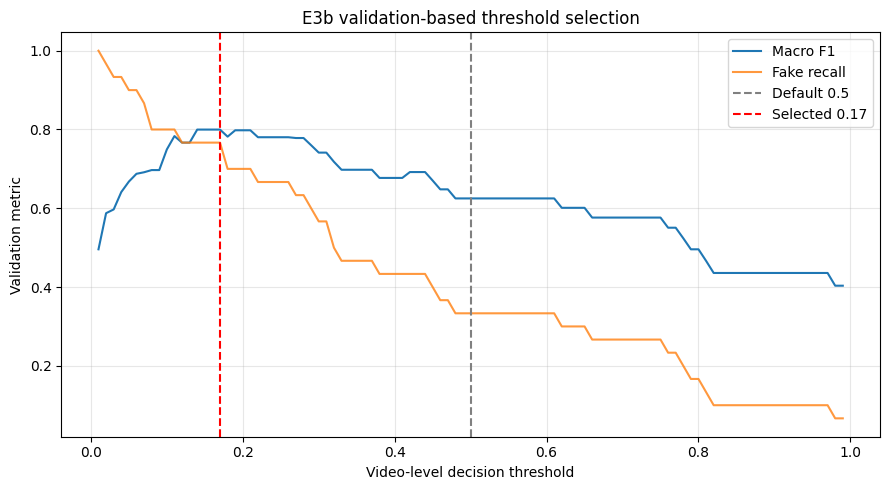

In [7]:
def metrics_at_threshold(labels, probabilities, threshold):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)
    matrix = confusion_matrix(labels, predictions, labels=[REAL_INDEX, FAKE_INDEX])
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(labels, predictions)),
        "macro_precision": float(precision_score(labels, predictions, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(labels, predictions, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(labels, predictions, average="macro", zero_division=0)),
        "real_recall": float(recall_score(labels, predictions, pos_label=REAL_INDEX, zero_division=0)),
        "fake_recall": float(recall_score(labels, predictions, pos_label=FAKE_INDEX, zero_division=0)),
        "roc_auc": float(roc_auc_score(labels, probabilities)),
        "confusion_matrix": matrix.tolist(),
    }

if RUN_VALIDATION_SELECTION:
    search_rows = [
        metrics_at_threshold(
            val_video_df["true_label"],
            val_video_df["mean_fake_probability"],
            threshold,
        )
        for threshold in CANDIDATE_THRESHOLDS
    ]
    search_df = pd.DataFrame(search_rows)
    search_df["distance_from_0_5"] = (search_df["threshold"] - DEFAULT_THRESHOLD).abs()
    ranked_df = search_df.sort_values(
        ["macro_f1", "fake_recall", "distance_from_0_5", "threshold"],
        ascending=[False, False, True, True],
        kind="mergesort",
    ).reset_index(drop=True)
    selected_threshold = float(ranked_df.loc[0, "threshold"])
    default_validation_metrics = metrics_at_threshold(
        val_video_df["true_label"], val_video_df["mean_fake_probability"], DEFAULT_THRESHOLD
    )
    selected_validation_metrics = metrics_at_threshold(
        val_video_df["true_label"], val_video_df["mean_fake_probability"], selected_threshold
    )

    display(ranked_df.head(10))
    print(f"Selected E3b-T threshold: {selected_threshold:.2f}")
    print("Selection rule:", SELECTION_METRIC, ";", TIE_BREAK_RULE)
    print("Default validation confusion matrix:", default_validation_metrics["confusion_matrix"])
    print("Selected validation confusion matrix:", selected_validation_metrics["confusion_matrix"])

    search_df.to_csv(SEARCH_CSV, index=False)
    plt.figure(figsize=(9, 5))
    plt.plot(search_df["threshold"], search_df["macro_f1"], label="Macro F1")
    plt.plot(search_df["threshold"], search_df["fake_recall"], label="Fake recall", alpha=0.8)
    plt.axvline(DEFAULT_THRESHOLD, color="grey", linestyle="--", label="Default 0.5")
    plt.axvline(selected_threshold, color="red", linestyle="--", label=f"Selected {selected_threshold:.2f}")
    plt.xlabel("Video-level decision threshold")
    plt.ylabel("Validation metric")
    plt.title("E3b validation-based threshold selection")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "e3b_validation_threshold_search.png", dpi=300)
    plt.show()
else:
    raise RuntimeError("RUN_VALIDATION_SELECTION must be True to produce a frozen threshold.")

## 7. Freeze the threshold and compare it with 0.5 on untouched domains

The selected value is carried forward without adjustment. Test-domain metrics are reported at both thresholds so that the application analysis does not replace the canonical $0.5$ evaluation.

In [8]:
comparison_rows = []
all_video_dfs = [val_video_df.copy()]

def append_domain_comparison(domain, video_df):
    for threshold_name, threshold in (("default", DEFAULT_THRESHOLD), ("selected_E3b_T", selected_threshold)):
        metrics = metrics_at_threshold(
            video_df["true_label"], video_df["mean_fake_probability"], threshold
        )
        comparison_rows.append({
            "domain": domain,
            "threshold_name": threshold_name,
            **metrics,
        })

append_domain_comparison("ffpp_validation", val_video_df)

if RUN_FFPP_TEST_COMPARISON:
    test_frame_df, test_video_df = infer_video_probabilities(test_dataset, "ffpp_test")
    append_domain_comparison("ffpp_test", test_video_df)
    all_video_dfs.append(test_video_df)

if RUN_CELEBDF_COMPARISON:
    if not (CELEB_FACES_DIR / "real").is_dir() or not (CELEB_FACES_DIR / "fake").is_dir():
        raise FileNotFoundError(CELEB_FACES_DIR)
    if not CELEB_MANIFEST_PATH.is_file():
        raise FileNotFoundError(CELEB_MANIFEST_PATH)
    with CELEB_MANIFEST_PATH.open("r", encoding="utf-8") as handle:
        celeb_manifest = json.load(handle)
    assert len(celeb_manifest["real_videos"]) == 20
    assert len(celeb_manifest["fake_videos"]) == 20
    assert celeb_manifest["frames_per_video"] == 10

    celeb_dataset = FaceCropDataset(CELEB_FACES_DIR, celeb_video_id)
    celeb_frame_df, celeb_video_df = infer_video_probabilities(celeb_dataset, "celebdf_v2_pilot")
    assert len(celeb_frame_df) == 400 and len(celeb_video_df) == 40
    assert celeb_video_df["number_of_frames"].eq(10).all()
    append_domain_comparison("celebdf_v2_pilot", celeb_video_df)
    all_video_dfs.append(celeb_video_df)

comparison_df = pd.DataFrame(comparison_rows)
display_columns = [
    "domain", "threshold_name", "threshold", "accuracy", "macro_f1",
    "real_recall", "fake_recall", "roc_auc", "confusion_matrix",
]
display(comparison_df[display_columns])
comparison_df.to_csv(COMPARISON_CSV, index=False)
pd.concat(all_video_dfs, ignore_index=True).to_csv(PREDICTIONS_CSV, index=False)

,domain,threshold_name,threshold,accuracy,macro_f1,real_recall,fake_recall,roc_auc,confusion_matrix
0,ffpp_validation,default,0.50,0.666667,0.625000,1.000000,0.333333,0.854444,"[[30, 0], [20, 10]]"
1,ffpp_validation,selected_E3b_T,0.17,0.800000,0.799778,0.833333,0.766667,0.854444,"[[25, 5], [7, 23]]"
2,ffpp_test,default,0.50,0.583333,0.495798,1.000000,0.166667,0.840000,"[[30, 0], [25, 5]]"
3,ffpp_test,selected_E3b_T,0.17,0.700000,0.682726,0.933333,0.466667,0.840000,"[[28, 2], [16, 14]]"
4,celebdf_v2_pilot,default,0.50,0.725000,0.710336,0.950000,0.500000,0.802500,"[[19, 1], [10, 10]]"
5,celebdf_v2_pilot,selected_E3b_T,0.17,0.675000,0.673162,0.600000,0.750000,0.802500,"[[12, 8], [5, 15]]"


## 8. Save the frozen operating point and auditable outputs

In [9]:
selection_record = {
    "configuration": "E3b-T",
    "base_model": "E3b official SBI EfficientNet-B0",
    "checkpoint": str(CHECKPOINT_PATH),
    "threshold_status": "secondary application-oriented operating point",
    "canonical_threshold_retained": DEFAULT_THRESHOLD,
    "selected_threshold": selected_threshold,
    "selection_domain": "FaceForensics++ validation face crops",
    "selection_level": "video",
    "video_aggregation": "mean fake probability across available frames",
    "selection_metric": SELECTION_METRIC,
    "candidate_thresholds": {"minimum": 0.01, "maximum": 0.99, "step": 0.01},
    "tie_break_rule": TIE_BREAK_RULE,
    "preprocessing": "RetinaFace crop; resize 224x224; RGB float32 scale [0,1]; no ImageNet normalisation",
    "class_to_index": {"real": REAL_INDEX, "fake": FAKE_INDEX},
    "fake_output_index": FAKE_INDEX,
    "validation_videos": int(len(val_video_df)),
    "default_validation_metrics": default_validation_metrics,
    "selected_validation_metrics": selected_validation_metrics,
    "test_or_external_labels_used_for_selection": False,
    "comparison_records": comparison_rows,
}

with SELECTION_JSON.open("w", encoding="utf-8") as handle:
    json.dump(selection_record, handle, indent=2)

print("Frozen threshold saved to:", SELECTION_JSON)
print("Threshold search saved to:", SEARCH_CSV)
print("Domain comparison saved to:", COMPARISON_CSV)
print("Video probabilities saved to:", PREDICTIONS_CSV)
print("Threshold-search plot saved to:", PLOTS_DIR / "e3b_validation_threshold_search.png")

Frozen threshold saved to: /content/drive/MyDrive/deepfake_project/results/threshold_selection/e3b_validation_threshold_selection.json
Threshold search saved to: /content/drive/MyDrive/deepfake_project/results/threshold_selection/e3b_validation_threshold_search.csv
Domain comparison saved to: /content/drive/MyDrive/deepfake_project/results/threshold_selection/e3b_threshold_comparison.csv
Video probabilities saved to: /content/drive/MyDrive/deepfake_project/results/threshold_selection/e3b_video_probabilities_all_domains.csv
Threshold-search plot saved to: /content/drive/MyDrive/deepfake_project/plots/threshold_selection/e3b_validation_threshold_search.png


## Methodological safeguards

- Only genuine FaceForensics++ validation real/fake samples determine the E3b-T threshold.
- Synthetic SBI samples are not used to select the operating point.
- The retained E3b weights are not retrained or altered.
- FaceForensics++ test and Celeb-DF v2 labels are excluded from selection.
- The chosen threshold is frozen before test-domain comparison.
- Results at $\tau=0.5$ remain the canonical model results; E3b-T is reported as a secondary application-oriented analysis.
- ROC-AUC is threshold-independent and therefore remains unchanged when the operating threshold changes.